In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cns.process.cluster import breaks_to_clusters, merge_clusters
from cns.process.breakpoints import get_breaks
from cns.data_utils import main_load_data

# auto reload modules
%load_ext autoreload
%autoreload 2

plt.rcParams.update({'font.size': 12 })


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
samples, cns = main_load_data()

In [22]:
dict_start = get_breaks(cns, False)
# Step 1: Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(dict_start, orient='index').transpose()

# Step 2: Calculate the breakpoints per chromosome
breakpoints_per_chr = pd.DataFrame({
    'Chromosome': list(dict_start.keys()),
    'Breakpoints': [len(value) for value in dict_start.values()]
}).set_index('Chromosome')

# Step 3: Calculate the total breakpoints
total_breakpoints = breakpoints_per_chr['Breakpoints'].sum()

# Step 4: Display the DataFrame and the total breakpoints
print("Breakpoints per chromosome:")
print(breakpoints_per_chr)
print("\nTotal breakpoints:", total_breakpoints)

Breakpoints per chromosome:
            Breakpoints
Chromosome             
chr1              65859
chr10             34571
chr11             46963
chr12             48370
chr13             23562
chr14             24772
chr15             19743
chr16             24469
chr17             33679
chr18             23059
chr19             27106
chr2              54925
chr20             23694
chr21             12271
chr22             13268
chr3              54722
chr4              42493
chr5              45869
chr6              51283
chr7              44709
chr8              52950
chr9              34110
chrX              29456
chrY                188

Total breakpoints: 832091


Text(0.5, 1.0, 'Merged breakpoints distribution in chromosome 1, distance 25kb')

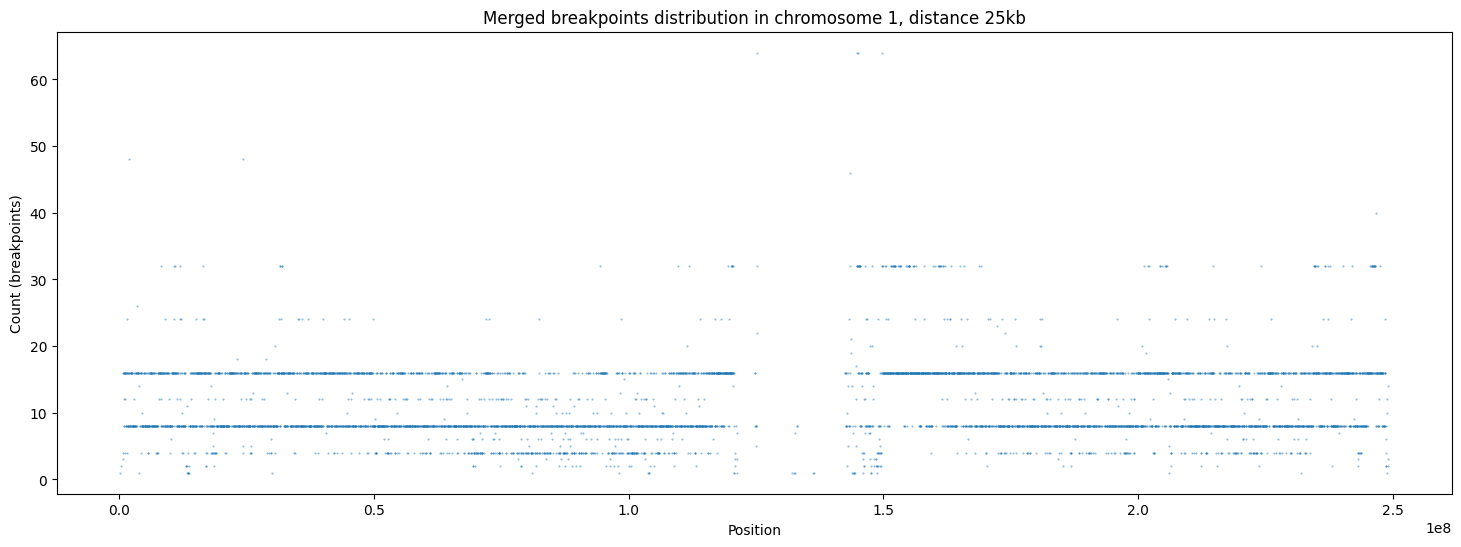

In [23]:
clusters = breaks_to_clusters(dict_start["chr1"])
merged_clusters = merge_clusters(clusters, 25000)

# set image size to 18x3
plt.figure(figsize=(18, 6))
plt.scatter(merged_clusters[:, 0], merged_clusters[:, 1], s=.25, alpha=0.5)
plt.xlabel("Position")
plt.ylabel("Count (breakpoints)")
plt.title("Merged breakpoints distribution in chromosome 1, distance 25kb")

In [17]:
def break_count(breaks):
    return sum(len(values) for values in breaks.values())

In [39]:
import time

from cns.process.cluster import calc_clusters, cluster_within_segments
from cns.utils.conversions import genome_to_segments
chr_clusters = {}
orig_count = break_count(dict_start)
print(f"Reducing {orig_count} breakpoints:")
distances =  [1000 * (2**i) for i in range(11)] 
counts = []
gen_segs = genome_to_segments()
for dist in distances:
    time_start = time.time()
    res = calc_clusters(dict_start, dist)
    counts.append(break_count(res))
    reduction = np.round(counts[-1] / orig_count * 100, 2)
    print(f"Dist: {dist}, count: {counts[-1]}, ratio: {reduction}%, time: {time.time() - time_start:.2f}s")

Reducing 832091 breakpoints:
Dist: 1000, count: 615466, ratio: 73.97%, time: 171.47s
Dist: 2000, count: 481038, ratio: 57.81%, time: 192.54s
Dist: 4000, count: 325775, ratio: 39.15%, time: 118.89s
Dist: 8000, count: 194750, ratio: 23.4%, time: 40.56s
Dist: 16000, count: 108927, ratio: 13.09%, time: 12.59s
Dist: 32000, count: 58531, ratio: 7.03%, time: 5.82s
Dist: 64000, count: 30343, ratio: 3.65%, time: 3.27s
Dist: 128000, count: 15469, ratio: 1.86%, time: 2.06s
Dist: 256000, count: 7839, ratio: 0.94%, time: 1.75s
Dist: 512000, count: 3959, ratio: 0.48%, time: 1.36s
Dist: 1024000, count: 1999, ratio: 0.24%, time: 1.28s


In [36]:
[1000 * (2**i) for i in range(11)] 

[1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000]

In [15]:
print(dict_start["chr1"][:10])

[0, 182499, 232499, 256651, 637029, 637200, 637568, 712600, 714190, 718252]


[ 9.96578428 10.96578428 11.96578428 12.96578428 13.96578428 14.96578428
 15.96578428 16.96578428 17.96578428 18.96578428 19.96578428]


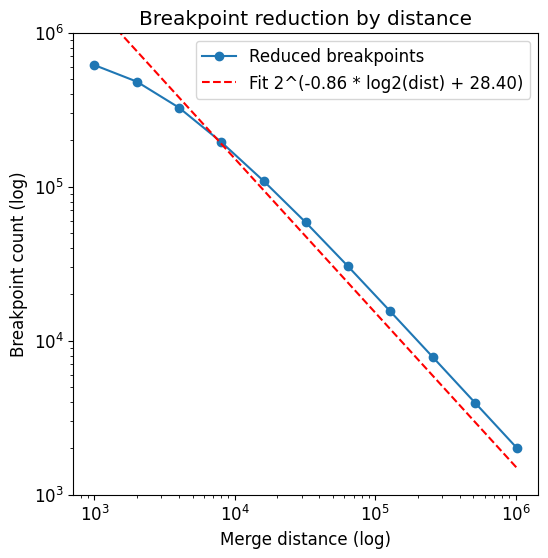

In [70]:
# set plot to 6x6
plt.figure(figsize=(6, 6))
# Step 1: Perform linear regression on the log-transformed data
log_distances = np.log2(distances)
log_counts = np.log2(counts)
slope, intercept = np.polyfit(log_distances, log_counts, 1)
print(log_distances)
# Step 2: Generate the linear fit line
fit_line = 2**(-1 * log_distances + 30.5)

# Step 3: Plot the original data and the fit line
plt.plot(distances, counts, marker='o', label='Reduced breakpoints')
plt.plot(distances, fit_line, linestyle='--', color='r', label='Fit 2^({:.2f} * log2(dist) + {:.2f})'.format(slope, intercept))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e3, 1e6)
plt.xlabel('Merge distance (log)')
plt.ylabel('Breakpoint count (log)')
plt.title('Breakpoint reduction by distance')
plt.legend()
plt.show()

In [ ]:
$